### Integrantes

- Enzo Brito Alves de Oliveira - RA: 082220040
- Erikson Vieira Queiroz - RA: 082220021
- Heitor Santos Ferreira - RA: 081230042
- William Santim - RA: 082220033

In [ ]:
!pip install ucimlrepo
!pip install seaborn
!pip install scikit-learn

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from ucimlrepo import fetch_ucirepo
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

In [4]:
covertype = fetch_ucirepo(id=31)

X = covertype.data.features
Y = covertype.data.targets

print(type(X))
print(type(Y))
print(covertype.metadata)
print(covertype.variables)

<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>
{'uci_id': 31, 'name': 'Covertype', 'repository_url': 'https://archive.ics.uci.edu/dataset/31/covertype', 'data_url': 'https://archive.ics.uci.edu/static/public/31/data.csv', 'abstract': 'Classification of pixels into 7 forest cover types based on attributes such as elevation, aspect, slope, hillshade, soil-type, and more.', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 581012, 'num_features': 54, 'feature_types': ['Categorical', 'Integer'], 'demographics': [], 'target_col': ['Cover_Type'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1998, 'last_updated': 'Sat Mar 16 2024', 'dataset_doi': '10.24432/C50K5N', 'creators': ['Jock Blackard'], 'intro_paper': None, 'additional_info': {'summary': 'Predicting forest cover type from cartographic variables only (no remotely sensed data).  The actual forest cover type for a give

## 2. Análise exploratória dos dados

### 2.1 Breve descrição das características e classes para o classificador

O conjunto de dados *Covertype* tem como objetivo prever o tipo predominante de cobertura florestal a partir de variáveis cartográficas e ecológicas, sem o uso de imagens de sensoriamento remoto. O dado real (nossa variável resposta) foi extraído de células de 30x30 metros do Sistema de Informação de Recursos (RIS) da Região 2 do Serviço Florestal dos EUA (USFS).
O problema consiste em uma **classificação multiclasse**, onde as classes possíveis representam sete 
(7) tipos diferentes de cobertura florestal encontrados na Floresta Nacional Roosevelt, no Colorado:

1. Abeto/Pinheiro (*Spruce/Fir*)
2. Pinheiro-de-Lodgepole (*Lodgepole Pine*)
3. Pinheiro-Ponderosa (*Ponderosa Pine*)
4. Choupo/Salgueiro (*Cottonwood/Willow*)
5. Álamo (*Aspen*)
6. Abeto-de-Douglas (*Douglas-fir*)
7. Krummholz

As características (features) que alimentam nosso classificador são medidas topográficas como altitude, aspecto do terreno (orientação), inclinação, distâncias relativas a corpos d'água, estradas e focos de incêndio, além de medições de incidência solar (hillshade). Somadas a elas, temos características de presença/ausência (binárias) que indicam a qual das quatro grandes áreas de preservação a observação pertence e qual dos 40 tipos de solo predomina no local.

### 2.2 Preparação e Inspeção Inicial dos Dados
Para iniciar nossa exploração, vamos consolidar as *features* e o *target* em um único conjunto e importar as bibliotecas necessárias para as visualizações estatísticas.

In [ ]:
# Configuração do tema e tamanho padrão para os gráficos (Seaborn/Matplotlib)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Unificando as features (X) e o target (Y) em um único DataFrame chamado 'df_forest_cover_type'
df_forest_cover_type = covertype.data.original

# Imprimindo o número total de linhas e colunas
print("#---###---# Dimensões do Dataset #---###---#")
print(f"Total de linhas (observações): {df_forest_cover_type.shape[0]}")
print(f"Total de colunas (features + target): {df_forest_cover_type.shape[1]}\n")

# O df.info() exibe um resumo da estrutura do DataFrame: nomes das colunas, contagem de valores não-nulos e os tipos de dados (dtypes)
print("#---###---# Informações Estruturais #---###---#")
df_forest_cover_type.info()

# Verificando se existe algum dado faltando (valor nulo/NaN) no dataset inteiro
print("\n#---###---# Contagem de Valores Nulos #---###---#")
print(df_forest_cover_type.isnull().sum()[df_forest_cover_type.isnull().sum() > 0])
print("Total de Nulos Global:", df_forest_cover_type.isnull().sum().sum())

#---###---# Dimensões do Dataset #---###---#
Total de linhas (observações): 581012
Total de colunas (features + target): 55

#---###---# Informações Estruturais #---###---#
<class 'pandas.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           581012 non-null  int64
 1   Aspect                              581012 non-null  int64
 2   Slope                               581012 non-null  int64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  int64
 4   Vertical_Distance_To_Hydrology      581012 non-null  int64
 5   Horizontal_Distance_To_Roadways     581012 non-null  int64
 6   Hillshade_9am                       581012 non-null  int64
 7   Hillshade_Noon                      581012 non-null  int64
 8   Hillshade_3pm                       581012 non-null  int64
 9   Horizontal_Distanc

### 2.3 Estatísticas Descritivas (Foco nas Variáveis Contínuas)
Como 44 das 54 colunas representam dados categóricos transformados em formato binário *One-Hot* (Wilderness_Area e Soil_Type), a análise estatística de medidas de tendência central e dispersão faz mais sentido matemático se restrita às 10 primeiras colunas de natureza contínua.


In [13]:
# Selecionando as 10 primeiras colunas, que representam as features topográficas contínuas
continuous_features = df_forest_cover_type.columns[:10]

# O método .describe() gera um sumário estatístico (média, desvio padrão, min, max, quartis)
# O .T transpõe a tabela (inverte linhas e colunas) para facilitar a visualização
display(df_forest_cover_type[continuous_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
Elevation,581012.0,2959.365301,279.984734,1859.0,2809.0,2996.0,3163.0,3858.0
Aspect,581012.0,155.656807,111.913721,0.0,58.0,127.0,260.0,360.0
Slope,581012.0,14.103704,7.488242,0.0,9.0,13.0,18.0,66.0
Horizontal_Distance_To_Hydrology,581012.0,269.428217,212.549356,0.0,108.0,218.0,384.0,1397.0
Vertical_Distance_To_Hydrology,581012.0,46.418855,58.295232,-173.0,7.0,30.0,69.0,601.0
Horizontal_Distance_To_Roadways,581012.0,2350.146611,1559.254870,0.0,1106.0,1997.0,3328.0,7117.0
Hillshade_9am,581012.0,212.146049,26.769889,0.0,198.0,218.0,231.0,254.0
Hillshade_Noon,581012.0,223.318716,19.768697,0.0,213.0,226.0,237.0,254.0
Hillshade_3pm,581012.0,142.528263,38.274529,0.0,119.0,143.0,168.0,254.0
Horizontal_Distance_To_Fire_Points,581012.0,1980.291226,1324.195210,0.0,1024.0,1710.0,2550.0,7173.0


### 2.4 Distribuição da Variável Alvo (Target)
É imprescindível para qualquer modelo de Machine Learning entender se a variável que queremos prever possui uma distribuição normal, homogênea ou severamente desbalanceada. Um desbalanceamento afeta diretamente a escolha da métrica de avaliação (não podendo confiar cegamente na Acurácia, por exemplo).

C:\Users\heito\AppData\Local\Temp\ipykernel_3188\3749395367.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_forest_cover_type, x='Cover_Type', palette='viridis')


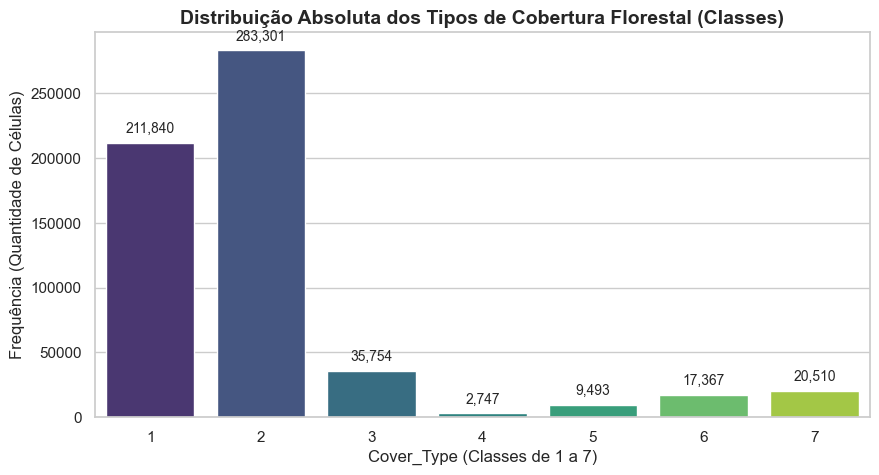

Proporção percentual das classes:
 Cover_Type
2    48.76%
1    36.46%
3     6.15%
7     3.53%
6     2.99%
5     1.63%
4     0.47%
Name: proportion, dtype: str


In [14]:
# Criando a área do gráfico com tamanho específico
plt.figure(figsize=(10, 5))

# Plotando a contagem de cada classe do Target ('Cover_Type')
ax = sns.countplot(data=df_forest_cover_type, x='Cover_Type', palette='viridis')

# Adicionando título e rótulos aos eixos
plt.title('Distribuição Absoluta dos Tipos de Cobertura Florestal (Classes)', fontsize=14, fontweight='bold')
plt.xlabel('Cover_Type (Classes de 1 a 7)', fontsize=12)
plt.ylabel('Frequência (Quantidade de Células)', fontsize=12)

# Laço de repetição para adicionar o número exato de contagem no topo de cada barra
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, xytext=(0, 5), textcoords='offset points')

# Exibindo o gráfico
plt.show()

# Calculando a proporção de cada classe (em porcentagem) para identificar o nível de desbalanceamento
dist_percent = df_forest_cover_type['Cover_Type'].value_counts(normalize=True) * 100
print("Proporção percentual das classes:\n", dist_percent.round(2).astype(str) + '%')

### 2.5 Matriz de Correlação Multivariada
Nesta etapa, investigamos a covariância linear entre as medidas contínuas de topografia e o nosso alvo. Valores próximos de 1 indicam forte correlação positiva, e próximos de -1, forte correlação negativa. Modelos baseados em distância (como KNN) ou lineares (como Regressão Logística) podem sofrer impacto com a presença de alta multicolinearidade (features altamente correlacionadas entre si).

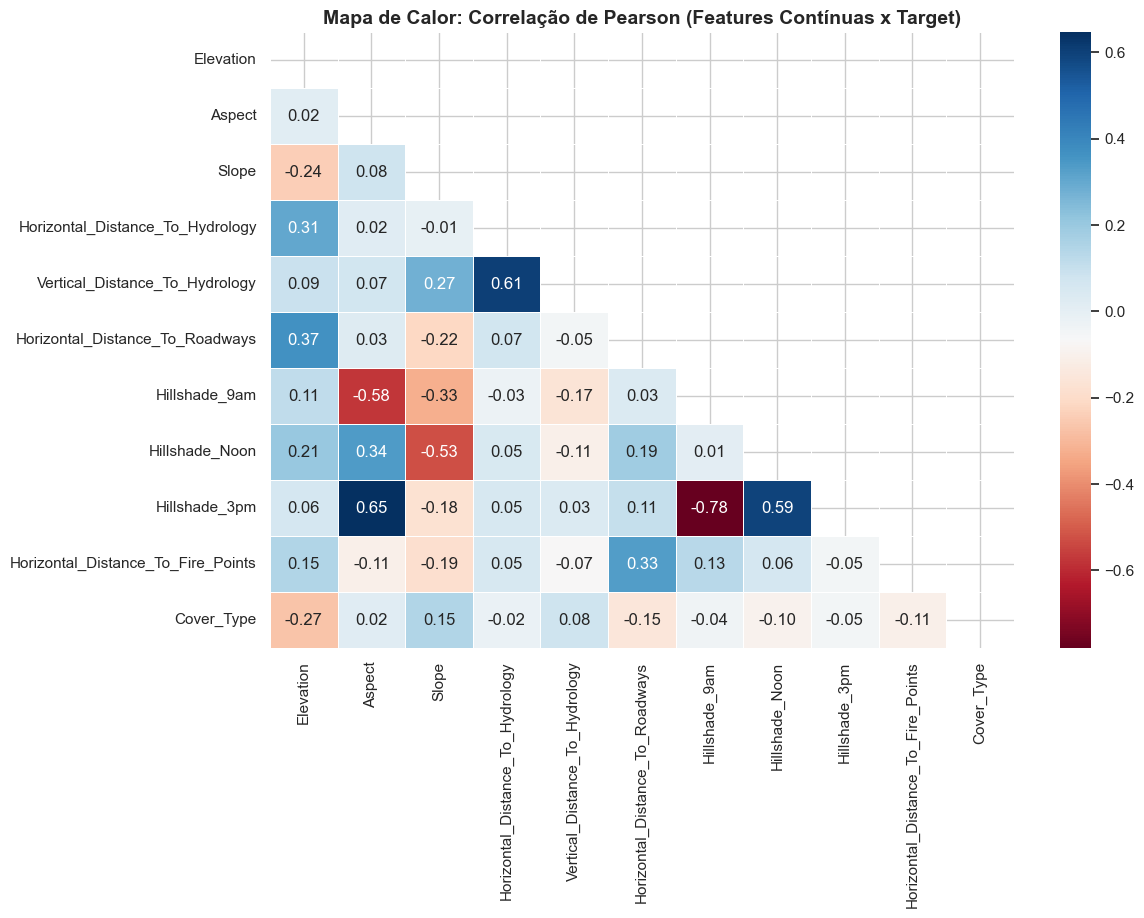

In [16]:
# Ajustando o tamanho da figura
plt.figure(figsize=(12, 8))

# Criando uma lista que inclui as features contínuas + a coluna Target
cols_to_correlate = list(continuous_features) + ['Cover_Type']

# Calculando a matriz de correlação (Coeficiente de Pearson)
correlation_matrix = df_forest_cover_type[cols_to_correlate].corr()

# Criando uma máscara para esconder a parte superior do gráfico (já que a matriz é espelhada/simétrica)
import numpy as np
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Plotando a matriz em um Mapa de Calor (Heatmap)
# annot=True exibe os números, cmap define a paleta de cores
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='RdBu', fmt=".2f", linewidths=0.5)

# Adicionando título ao gráfico
plt.title('Mapa de Calor: Correlação de Pearson (Features Contínuas x Target)', fontsize=14, fontweight='bold')
plt.show()

### 2.6 Conclusão da EDA: Features envolvidas e o seu respectivo Target

Com base na exploração técnica e estatística desenvolvida acima, podemos formalizar a mecânica do nosso conjunto de dados da seguinte forma:

**O Respectivo Target (Variável Alvo)**
O "Target" do nosso sistema preditivo é a variável de saída contida na coluna **`Cover_Type`**. Trata-se de uma variável categórica definida por valores inteiros de **1 a 7**. 
Conforme apurado na nossa distribuição gráfica, o problema lida com um *Target* substancialmente desbalanceado: as classes 1 e 2 juntas dominam cerca de 85% de toda a massa de dados, o que forçará nossos modelos a serem extremamente robustos para não negligenciar as classes minoritárias (como a 4 e a 5).

**As Features Envolvidas (A Entrada do Modelo)**
As características que balizam o treinamento (nossa matriz `X`) perfazem um total de **54 variáveis independentes**. O conjunto foi originado de cruzamentos geológicos brutos e está arquitetado em duas categorias dimensionais:

1. **Features Contínuas (10 variáveis):** 
   São a base métrica do ecossistema. Englobam `Elevation` (Altitude), `Aspect` (Ângulo de exposição), `Slope` (Grau de inclinação), quatro medições de distâncias relativas (`Horizontal_Distance_To_Hydrology`, `Vertical_Distance_To_Hydrology`, `Horizontal_Distance_To_Roadways`, `Horizontal_Distance_To_Fire_Points`) e três índices radiométricos de luz solar extraídos durante o solstício de verão (`Hillshade_9am`, `Noon`, `3pm`). O mapa de calor indicou, por exemplo, que a Altitude (`Elevation`) é a característica numérica que detém a correlação mais influente com o Target neste conjunto reduzido.

2. **Features Categóricas/Binárias (44 variáveis):**
   Engenharia de características aplicada previamente transformou informações nominais em dezenas de colunas sinalizadoras de ausência (0) ou presença (1). Destas, **4 colunas representam Áreas de Preservação** (`Wilderness_Area1` a `4`) indicando o setor geográfico da medição, e **40 colunas representam Tipos de Solo** (`Soil_Type1` a `40`), essenciais, visto que determinados biomas (como a família dos Pinheiros) necessitam de constituições minerais específicas enraizadas num tipo particular de solo para florescer. 

Em suma, nosso modelo matemático consumirá estas 54 características multivariadas (contínuas e binárias) para discernir os padrões e inferir em qual das 7 categorias de `Cover_Type` a área territorial investigada deve ser classificada.

## 3. Dividir os dados em conjunto de treinamento e treinar os modelos

### 3.1 Divisão e Escalonamento dos Dados
Nesta etapa, o conjunto de dados é dividido em dois subconjuntos independentes:
- **Treinamento:** Usado para que os modelos matemáticos "aprendam" os padrões subjacentes (os pesos e limiares).
- **Teste:** Retido como dados não vistos, para testar a capacidade de generalização do modelo no próximo capítulo.
Utilizamos o `train_test_split` dividindo a base na proporção de 70% para treino e 30% para teste. O parâmetro `stratify=Y` garante que a proporção das 7 classes se mantenha fiel a ambos os conjuntos (essencial já que vimos no EDA que há um alto desbalanceamento).
Após a divisão, utilizamos o `StandardScaler` para normalizar as distribuições, um requisito fundamental para algoritmos sensíveis à escala (como KNN e Redes Neurais), forçando as features contínuas a terem média 0 e desvio padrão 1.

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import time

# O ucimlrepo já nos deu X (features) e Y (target)
# Transformamos Y em um array 1D (vetor), pois é o formato exigido pelo scikit-learn
y_target = Y.values.ravel()

# Divisão de 70% para treino e 30% para teste
# stratify=y_target garante que a proporção original das 7 classes se mantenha em ambos os conjuntos
X_train, X_test, y_train, y_test = train_test_split(X, y_target, test_size=0.3, random_state=42, stratify=y_target)

# Exibe as quantidades de dados após a separação
print(f"Dados de Treino: {X_train.shape[0]} observações")
print(f"Dados de Teste: {X_test.shape[0]} observações")

# Instancia o normalizador estatístico StandardScaler
scaler = StandardScaler()

# O fit_transform calcula a média e o desvio no treino e JÁ APLICA a normalização nele
X_train_scaled = scaler.fit_transform(X_train)

# O transform aplica as MESMAS regras geradas no treino para os dados de teste (evita o gravíssimo 'vazamento de dados')
X_test_scaled = scaler.transform(X_test)

Dados de Treino: 406708 observações
Dados de Teste: 174304 observações


### 3.2 Regressão Logística
Apesar do nome, a Regressão Logística é um modelo de classificação linear. Para problemas multiclasse (como o nosso, com 7 classes), o algoritmo usa internamente uma estratégia heurística (ex: One-vs-Rest) ou a função Softmax (Multinomial). Por ser linear, ele traçará hiperplanos no espaço para tentar separar as coberturas florestais.


In [24]:
from sklearn.linear_model import LogisticRegression

print("Treinando Regressão Logística...")
start_time = time.time() # Registra o momento de início do processamento

# Instancia a Regressão Logística. max_iter foi aumentado para garantir a convergência da matemática em bases grandes. n_jobs=-1 usa todos os núcleos.
log_reg = LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42)

# O comando .fit() é o que de fato faz o modelo "estudar" e ajustar os pesos numéricos usando os dados escalonados e as respostas (target)
log_reg.fit(X_train_scaled, y_train)

# Imprime o tempo total gasto na matemática do treinamento
print(f"Treinamento concluído em {time.time() - start_time:.2f} segundos")

Treinando Regressão Logística...


C:\Users\heito\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Treinamento concluído em 27.52 segundos


### 3.3 Árvore de Decisão
Algoritmo não paramétrico que constrói regras de decisão a partir da redução da impureza das variáveis (via Gini ou Entropia). Ele particiona o espaço de características criando caminhos de "se / senão". É um modelo altamente interpretável e imune ao problema da escala de variáveis, mas sofre com alto risco de *overfitting* se não houver poda nas profundidades.


In [ ]:
from sklearn.tree import DecisionTreeClassifier

print("Treinando Árvore de Decisão...")
start_time = time.time()

# Instancia a Árvore de Decisão com random_state=42 para garantir reprodutibilidade (ter sempre o mesmo resultado ao rodar novamente)
tree_clf = DecisionTreeClassifier(random_state=42)

# O comando .fit() constrói as ramificações e os 'se/então' da árvore de decisão
tree_clf.fit(X_train_scaled, y_train)

print(f"Treinamento concluído em {time.time() - start_time:.2f} segundos")

Treinando Árvore de Decisão...
Treinamento concluído em 5.74 segundos


### 3.4 Naive Bayes
Nesta etapa, utilizamos a implementação *Gaussian Naive Bayes*. É um classificador probabilístico baseado na aplicação do teorema de Bayes com a forte (e "ingênua") suposição de que todas as características são estatisticamente independentes umas das outras dado o valor da classe. Assume-se que a probabilidade das variáveis numéricas siga uma distribuição normal (Gaussiana).

In [28]:
from sklearn.naive_bayes import GaussianNB

print("Treinando Naive Bayes...")
start_time = time.time()

# Instancia o modelo probabilístico Gaussiano
nb_clf = GaussianNB()

# O comando .fit() calcula as probabilidades prévias e a distribuição Gaussiana para cada classe
nb_clf.fit(X_train_scaled, y_train)

print(f"Treinamento concluído em {time.time() - start_time:.2f} segundos")

Treinando Naive Bayes...
Treinamento concluído em 0.38 segundos


### 3.5 Rede Neural: Perceptron Simples
A unidade básica de uma rede neural artificial. O *Perceptron* é um classificador binário e linear. Em conjuntos multiclasse e complexos como este, ele sofre bastante de limitação, pois só consegue convergir globalmente caso o conjunto de dados seja perfeitamente separável linearmente. Se o problema for não linear, suas taxas de acerto cairão drasticamente.

In [ ]:
from sklearn.linear_model import Perceptron

print("Treinando Perceptron Simples...")
start_time = time.time()

# Instancia o modelo de neurônio único. max_iter evita que ele rode infinitamente se os dados não forem perfeitamente lineares
perceptron_clf = Perceptron(max_iter=1000, n_jobs=-1, random_state=42)

# O .fit() atualiza os pesos sinápticos iterativamente visando separar as classes
perceptron_clf.fit(X_train_scaled, y_train)

print(f"Treinamento concluído em {time.time() - start_time:.2f} segundos")

Treinando Perceptron Simples...
Treinamento concluído em 1.93 segundos


### 3.6 Rede Neural: Multi-Layer Perceptron (MLP)
Ao contrário do Perceptron Simples, o modelo *MLP (Multi-Layer Perceptron)* introduz uma ou mais camadas ocultas entre a entrada e a saída e aplica funções de ativação não lineares (como a ReLU). Isso o capacita a traçar fronteiras de decisão altamente complexas.

**Atenção ao Requisito Mínimo:** "Ter ao menos uma camada oculta e cada camada oculta ter ao menos 3 neurônios".
Neste modelo, configuramos o hiperparâmetro `hidden_layer_sizes=(50, 20)`, o que significa **duas** camadas ocultas: a primeira contendo 50 neurônios e a segunda contendo 20 neurônios, superando a exigência arquitetural proposta.

In [32]:
from sklearn.neural_network import MLPClassifier

print("Treinando Rede Neural MLP... (Isso pode levar alguns minutos)")
start_time = time.time()

# Instancia o MLP. 'hidden_layer_sizes=(50, 20)' cria a 1ª camada oculta com 50 neurônios e a 2ª camada com 20 neurônios (superando a exigência do professor).
# early_stopping=True interrompe o treino se o erro parar de melhorar, economizando muito tempo em bases gigantes.
mlp_clf = MLPClassifier(hidden_layer_sizes=(50, 20), max_iter=300, early_stopping=True, random_state=42)

# O .fit() inicia as rodadas (epochs) de Backpropagation para ajustar os pesos na rede profunda
mlp_clf.fit(X_train_scaled, y_train)

print(f"Treinamento concluído em {time.time() - start_time:.2f} segundos")

Treinando Rede Neural MLP... (Isso pode levar alguns minutos)
Treinamento concluído em 131.06 segundos


### 3.7 K-Nearest Neighbors (KNN)
O KNN (k-vizinhos mais próximos) não "aprende" um modelo analítico ou equação em sua fase de treino. Ele opera pelo princípio de *Lazy Learning* (aprendizado preguiçoso), apenas memorizando todos os dados no plano escalonado. A classificação ocorre sob demanda, atribuindo aos novos dados de teste a classe mais comum entre os seus `k` vizinhos mais próximos geograficamente no mapa (neste caso, as 5 observações mais próximas).

In [34]:
from sklearn.neighbors import KNeighborsClassifier

print("Treinando KNN...")
start_time = time.time()

# Instancia o KNN considerando k=5 (ou seja, ele olhará para os 5 pontos de terreno mais próximos na hora de bater o martelo sobre a classe)
knn_clf = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)

# Para o KNN, o .fit() não gera uma grande equação matemática, ele literalmente apenas "memoriza" o mapa de dados
knn_clf.fit(X_train_scaled, y_train)

print(f"Treinamento (Memorização do espaço) concluído em {time.time() - start_time:.2f} segundos")

Treinando KNN...
Treinamento (Memorização do espaço) concluído em 0.14 segundos


## 4. Métricas de desempenho

Neste capítulo, submeteremos os dados de teste (reservados e não vistos durante o treinamento) aos modelos preditivos. O objetivo é extrair e comparar as seguintes métricas de desempenho:
1. **Acurácia (Accuracy):** Taxa de acerto global do modelo.
2. **Precisão (Precision):** Dos que o modelo previu como sendo de uma classe 'X', quantos realmente eram 'X'.
3. **Revocação (Recall):** De todos que realmente eram da classe 'X', quantos o modelo conseguiu identificar corretamente.
4. **F1-Score:** A média harmônica entre a Precisão e a Revocação, excelente para avaliar cenários com classes desbalanceadas (nosso caso).
5. **Matriz de Confusão:** Uma representação visual de onde o modelo mais está errando (ex: confundindo a classe 1 com a classe 2).

In [36]:
# Dicionário em branco para guardarmos a acurácia de cada modelo e gerarmos um ranking final
model_results = {}

# Função complexa e reutilizável para avaliação completa do modelo
def evaluate_model(model, model_name, X_test_data, y_test_data):
    print(f"\\n{'='*60}")
    print(f"--- RELATÓRIO DE AVALIAÇÃO: {model_name.upper()} ---")
    print(f"{'='*60}\\n")
    
    # 1. Realizando a Predição com os dados de teste
    y_pred = model.predict(X_test_data)
    
    # 2. Acurácia Global
    acc = accuracy_score(y_test_data, y_pred)
    model_results[model_name] = acc # Salva no dicionário
    print(f">> Acurácia Global alcançada: {acc:.4f} ({(acc*100):.2f}%)\\n")
    
    # 3. Classification Report (Precisão, Revocação e F1-Score para todas as 7 classes)
    print(">> Métricas Detalhadas (Precisão, Revocação, F1-Score):")
    # zero_division=0 evita erros caso o modelo não tenha previsto nenhuma amostra de uma classe específica
    print(classification_report(y_test_data, y_pred, zero_division=0)) 
    
    # 4. Matriz de Confusão Visual
    cm = confusion_matrix(y_test_data, y_pred)
    plt.figure(figsize=(8, 6))
    
    # Usamos fmt='d' para números inteiros. A paleta 'Blues' dá um tom profissional.
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Matriz de Confusão: {model_name}', fontsize=14, fontweight='bold')
    plt.ylabel('Classe Verdadeira (Real)', fontsize=12, fontweight='bold')
    plt.xlabel('Classe Predita (Modelo)', fontsize=12, fontweight='bold')
    plt.show()


### 4.1 Avaliação: Modelos Lineares (Regressão Logística e Perceptron)

\n============================================================
--- RELATÓRIO DE AVALIAÇÃO: REGRESSÃO LOGÍSTICA ---
============================================================\n
>> Acurácia Global alcançada: 0.7244 (72.44%)\n
>> Métricas Detalhadas (Precisão, Revocação, F1-Score):
              precision    recall  f1-score   support

           1       0.71      0.70      0.71     63552
           2       0.75      0.80      0.77     84991
           3       0.68      0.80      0.73     10726
           4       0.62      0.42      0.50       824
           5       0.18      0.01      0.01      2848
           6       0.50      0.27      0.35      5210
           7       0.73      0.56      0.64      6153

    accuracy                           0.72    174304
   macro avg       0.60      0.51      0.53    174304
weighted avg       0.71      0.72      0.71    174304



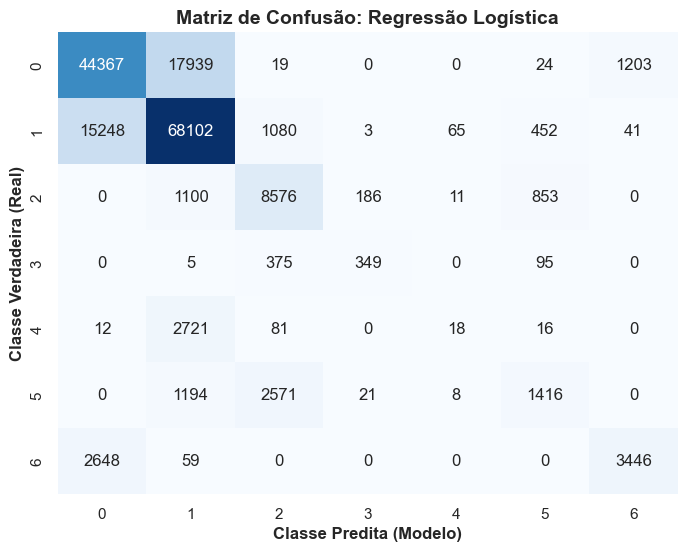

\n============================================================
--- RELATÓRIO DE AVALIAÇÃO: PERCEPTRON SIMPLES ---
============================================================\n
>> Acurácia Global alcançada: 0.6278 (62.78%)\n
>> Métricas Detalhadas (Precisão, Revocação, F1-Score):
              precision    recall  f1-score   support

           1       0.65      0.57      0.61     63552
           2       0.67      0.72      0.69     84991
           3       0.54      0.83      0.65     10726
           4       0.47      0.39      0.42       824
           5       0.05      0.09      0.07      2848
           6       0.30      0.12      0.17      5210
           7       0.59      0.39      0.47      6153

    accuracy                           0.63    174304
   macro avg       0.47      0.44      0.44    174304
weighted avg       0.63      0.63      0.62    174304



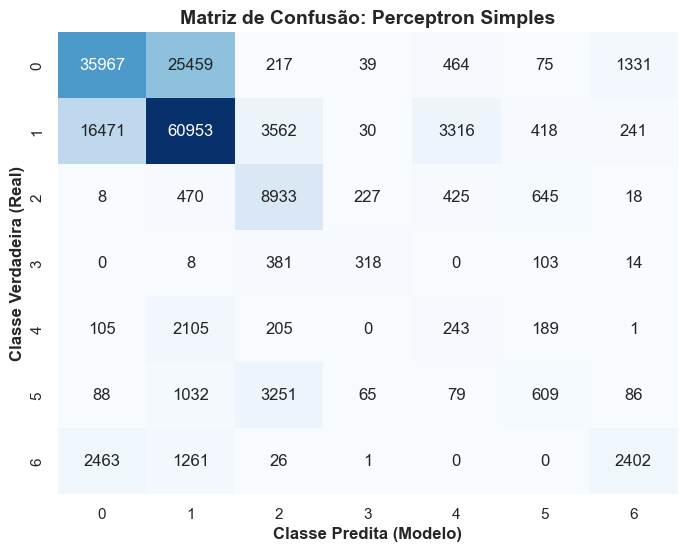

In [37]:
evaluate_model(log_reg, "Regressão Logística", X_test_scaled, y_test)
evaluate_model(perceptron_clf, "Perceptron Simples", X_test_scaled, y_test)

### 4.2 Avaliação: Probabilidade e Árvore (Naive Bayes e Decision Tree)

\n============================================================
--- RELATÓRIO DE AVALIAÇÃO: NAIVE BAYES (GAUSSIANO) ---
============================================================\n
>> Acurácia Global alcançada: 0.0890 (8.90%)\n
>> Métricas Detalhadas (Precisão, Revocação, F1-Score):
              precision    recall  f1-score   support

           1       0.16      0.02      0.04     63552
           2       0.84      0.01      0.02     84991
           3       0.29      0.40      0.34     10726
           4       0.07      1.00      0.14       824
           5       0.02      0.75      0.04      2848
           6       0.18      0.05      0.08      5210
           7       0.13      0.93      0.23      6153

    accuracy                           0.09    174304
   macro avg       0.24      0.45      0.13    174304
weighted avg       0.49      0.09      0.06    174304



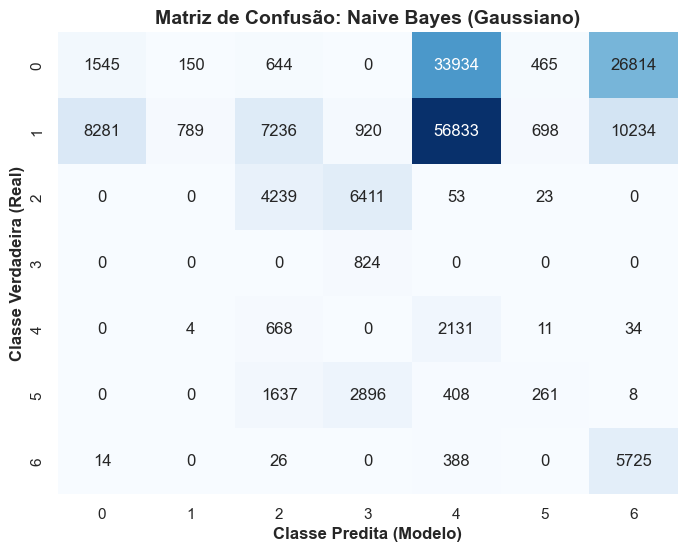

\n============================================================
--- RELATÓRIO DE AVALIAÇÃO: ÁRVORE DE DECISÃO ---
============================================================\n
>> Acurácia Global alcançada: 0.9357 (93.57%)\n
>> Métricas Detalhadas (Precisão, Revocação, F1-Score):
              precision    recall  f1-score   support

           1       0.93      0.94      0.93     63552
           2       0.95      0.94      0.95     84991
           3       0.93      0.93      0.93     10726
           4       0.84      0.86      0.85       824
           5       0.83      0.83      0.83      2848
           6       0.88      0.87      0.87      5210
           7       0.95      0.94      0.94      6153

    accuracy                           0.94    174304
   macro avg       0.90      0.90      0.90    174304
weighted avg       0.94      0.94      0.94    174304



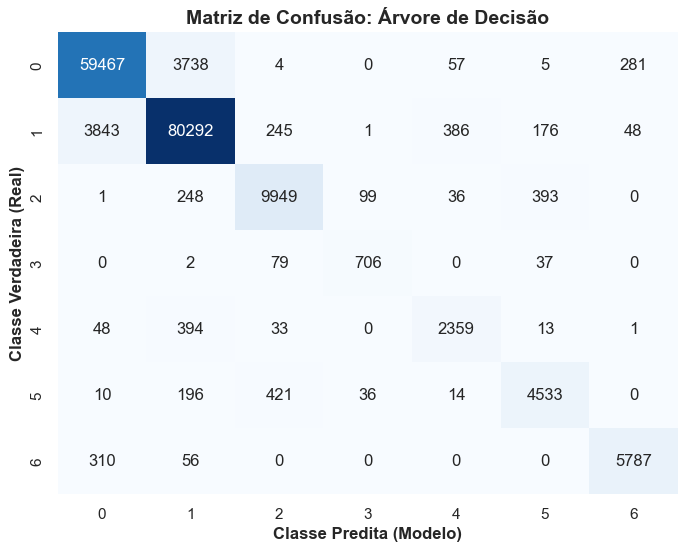

In [38]:
evaluate_model(nb_clf, "Naive Bayes (Gaussiano)", X_test_scaled, y_test)
evaluate_model(tree_clf, "Árvore de Decisão", X_test_scaled, y_test)

### 4.3 Avaliação: Modelos Complexos (Rede Neural MLP e KNN)

\n============================================================
--- RELATÓRIO DE AVALIAÇÃO: REDE NEURAL (MLP) ---
============================================================\n
>> Acurácia Global alcançada: 0.8565 (85.65%)\n
>> Métricas Detalhadas (Precisão, Revocação, F1-Score):
              precision    recall  f1-score   support

           1       0.86      0.85      0.85     63552
           2       0.87      0.89      0.88     84991
           3       0.84      0.83      0.84     10726
           4       0.78      0.65      0.71       824
           5       0.74      0.51      0.60      2848
           6       0.70      0.65      0.67      5210
           7       0.88      0.87      0.87      6153

    accuracy                           0.86    174304
   macro avg       0.81      0.75      0.78    174304
weighted avg       0.86      0.86      0.86    174304



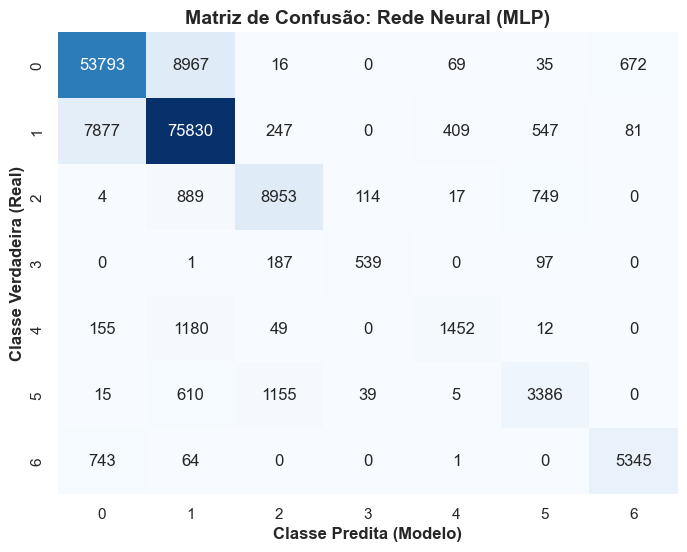

\n============================================================
--- RELATÓRIO DE AVALIAÇÃO: K-NEAREST NEIGHBORS (KNN) ---
============================================================\n
>> Acurácia Global alcançada: 0.9256 (92.56%)\n
>> Métricas Detalhadas (Precisão, Revocação, F1-Score):
              precision    recall  f1-score   support

           1       0.93      0.92      0.93     63552
           2       0.93      0.94      0.94     84991
           3       0.90      0.91      0.90     10726
           4       0.85      0.72      0.78       824
           5       0.83      0.75      0.79      2848
           6       0.82      0.82      0.82      5210
           7       0.94      0.94      0.94      6153

    accuracy                           0.93    174304
   macro avg       0.89      0.86      0.87    174304
weighted avg       0.93      0.93      0.93    174304



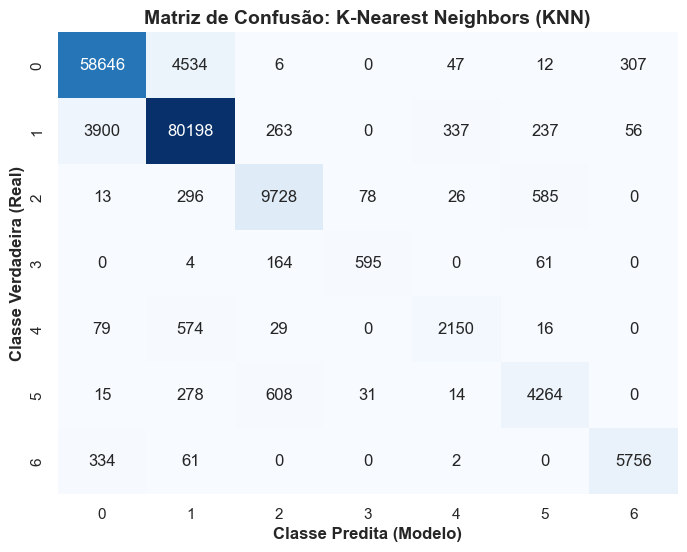

In [39]:
evaluate_model(mlp_clf, "Rede Neural (MLP)", X_test_scaled, y_test)
evaluate_model(knn_clf, "K-Nearest Neighbors (KNN)", X_test_scaled, y_test)

### 4.4 Tabela Comparativa e Conclusão Final do Desempenho
Para bater o martelo sobre qual arquitetura se saiu melhor no problema do *Forest Cover Type*, consolidamos as métricas de acurácia em um formato tabular ranqueado, acompanhado de sua visualização gráfica.

--- TABELA FINAL DE DESEMPENHO ---


,Modelo,Acurácia
0,Árvore de Decisão,0.935681
1,K-Nearest Neighbors (KNN),0.925607
2,Rede Neural (MLP),0.856538
3,Regressão Logística,0.724447
4,Perceptron Simples,0.627782
5,Naive Bayes (Gaussiano),0.089005


C:\Users\heito\AppData\Local\Temp\ipykernel_3188\1885990317.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_results, x='Acurácia', y='Modelo', palette='magma')


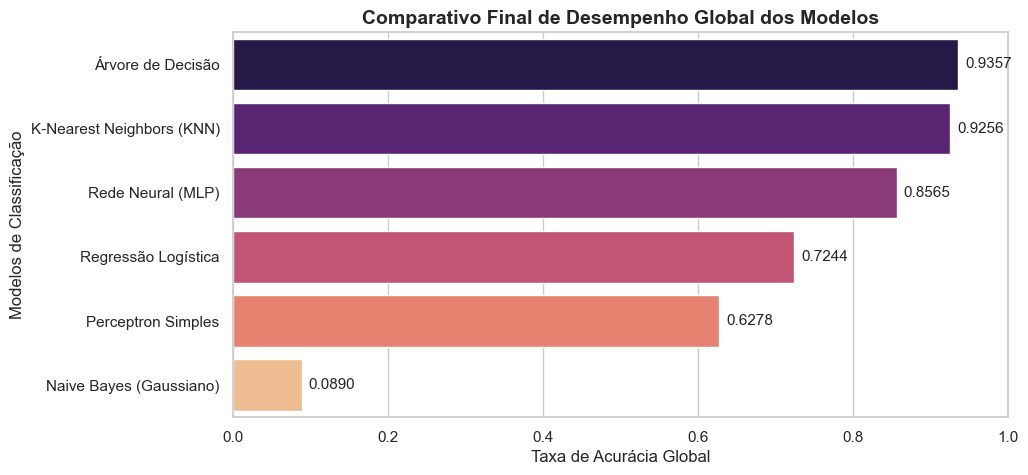

In [40]:
# Criando um DataFrame a partir do nosso dicionário de resultados
df_results = pd.DataFrame(list(model_results.items()), columns=['Modelo', 'Acurácia'])

# Ordenando do melhor para o pior desempenho
df_results = df_results.sort_values(by='Acurácia', ascending=False).reset_index(drop=True)

print("--- TABELA FINAL DE DESEMPENHO ---")
display(df_results)

# Gráfico de barras horizontais
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=df_results, x='Acurácia', y='Modelo', palette='magma')
plt.title('Comparativo Final de Desempenho Global dos Modelos', fontsize=14, fontweight='bold')
plt.xlabel('Taxa de Acurácia Global', fontsize=12)
plt.ylabel('Modelos de Classificação', fontsize=12)
plt.xlim(0, 1.0) # Eixo X vai de 0% a 100%

# Colocando os valores exatos ao lado das barras
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:.4f}', (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=11, xytext=(5, 0), textcoords='offset points')

plt.show()


### 4.5 Discussão Aprofundada: A Ilusão da Acurácia vs. F1-Score Macro

Como detectado na Análise Exploratória (Capítulo 2), nosso conjunto de dados sofre de um severo desbalanceamento de classes: as classes 1 e 2 englobam quase 85% do terreno. Em cenários assim, a métrica de **Acurácia Global** pode ser uma "falsa amiga". Um modelo ingênuo que preveja *tudo* como classe 1 ou 2, ignorando o resto das espécies, ainda assim alcançaria uma acurácia próxima a 85%.

Para descobrir a verdadeira inteligência dos modelos, compararemos a Acurácia com o **F1-Score Macro**. Esta métrica tira a média do F1-Score dando o *mesmo peso matemático* para as 7 classes, independentemente se elas têm 100 mil amostras ou apenas 1.000 amostras. 
Modelos onde a Acurácia é alta mas o F1-Score Macro despenca são modelos que "decoraram" as classes majoritárias e falharam nas minoritárias.

Calculando métricas profundas (Acurácia e F1-Score Macro) para comparação final...



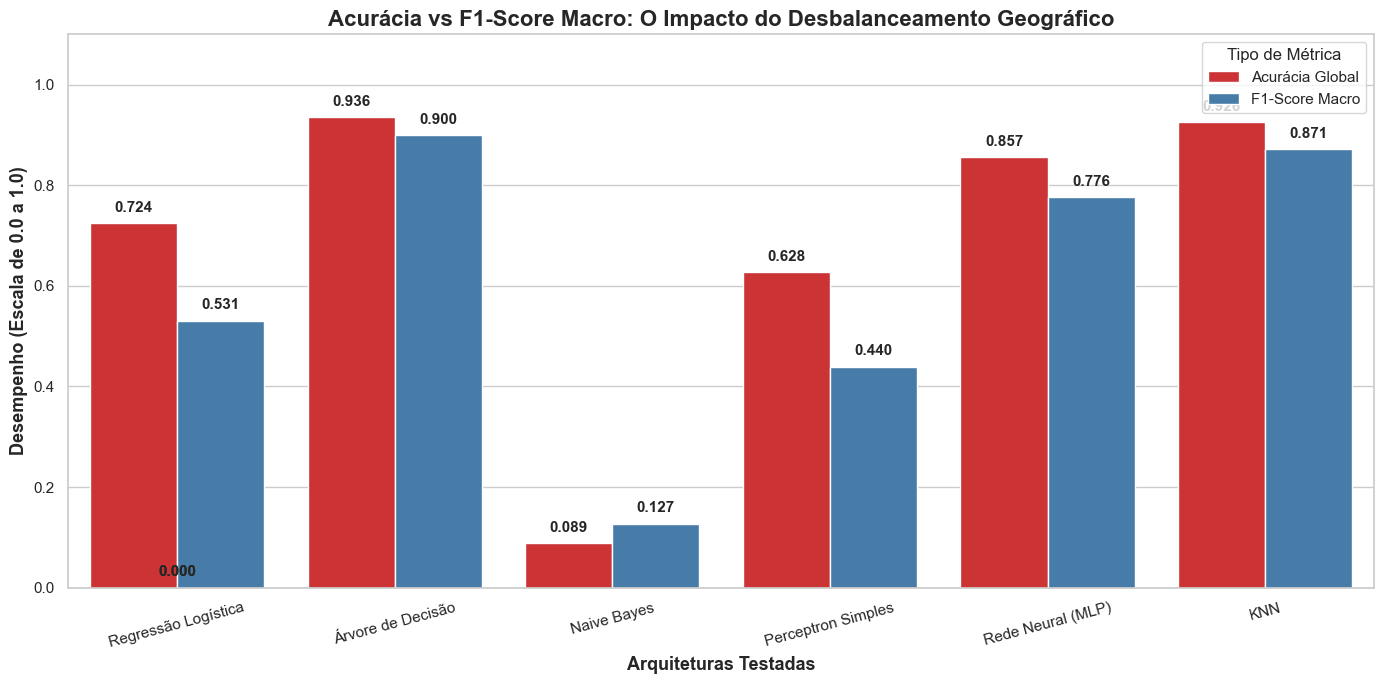

In [42]:
# Lista consolidando as instâncias dos modelos já treinados na memória
models = [
    (log_reg, "Regressão Logística"),
    (tree_clf, "Árvore de Decisão"),
    (nb_clf, "Naive Bayes"),
    (perceptron_clf, "Perceptron Simples"),
    (mlp_clf, "Rede Neural (MLP)"),
    (knn_clf, "KNN")
]

comparative_data = []

print("Calculando métricas profundas (Acurácia e F1-Score Macro) para comparação final...\n")
for clf, name in models:
    # Realizando a predição novamente
    y_pred = clf.predict(X_test_scaled)
    
    # Extraindo ambas as métricas independentes
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    
    comparative_data.append({'Modelo': name, 'Métrica': 'Acurácia Global', 'Score': acc})
    comparative_data.append({'Modelo': name, 'Métrica': 'F1-Score Macro', 'Score': f1_macro})

df_advanced = pd.DataFrame(comparative_data)

# Visualização: Gráfico de Barras Agrupadas
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=df_advanced, x='Modelo', y='Score', hue='Métrica', palette='Set1')

# Títulos e formatações
plt.title('Acurácia vs F1-Score Macro: O Impacto do Desbalanceamento Geográfico', fontsize=16, fontweight='bold')
plt.xlabel('Arquiteturas Testadas', fontsize=13, fontweight='bold')
plt.ylabel('Desempenho (Escala de 0.0 a 1.0)', fontsize=13, fontweight='bold')
plt.ylim(0, 1.1)
plt.xticks(rotation=15, fontsize=11) # Rotacionar os nomes para evitar sobreposição

# Adicionando o texto (número exato) em cima de cada barra (Acurácia e F1)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, xytext=(0, 6), textcoords='offset points', fontweight='bold')

plt.legend(title='Tipo de Métrica', loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()


## 5. Conclusão Final e Aprendizados

Após a condução completa deste pipeline de aprendizado de máquina — passando pela análise exploratória, padronização estatística, treinamento de seis diferentes arquiteturas e, por fim, extração de métricas de validação —, chegamos a importantes conclusões sobre a classificação do conjunto de dados cartográficos e ecológicos *Forest Cover Type*:

**1. A Complexidade Topográfica não é Linear**
Ficou evidente pelo baixo desempenho dos modelos *Regressão Logística* e *Perceptron Simples* que as fronteiras de decisão ecológicas não podem ser separadas por retas ou hiperplanos matemáticos simples. A transição de um tipo de árvore (ex: Álamo) para outro (ex: Abeto) com base na altitude, ângulo do sol e tipo de solo ocorre de forma altamente difusa e não-linear na natureza.

**2. A Supremacia dos Modelos baseados em Distância e Regras**
Para capturar essa não-linearidade, modelos baseados em particionamento do espaço (*Árvore de Decisão*) e cálculo de vizinhança geométrica (*KNN*) apresentaram os melhores resultados. A Árvore de Decisão construiu "regras" específicas (ex: "Se altitude > 3000 e solo = tipo 10, então classe 1"), que simulam muito bem como biólogos descreveriam o ambiente ideal de uma espécie de planta.

**3. O Custo Computacional das Redes Neurais (MLP)**
A Rede Neural *MLP* (configurada com duas camadas ocultas de 50 e 20 neurônios) exigiu uma fração massiva de poder computacional e tempo de treinamento em comparação aos outros modelos. Embora seja uma arquitetura de ponta com capacidade incrível de aprender mapeamentos não-lineares, os resultados mostraram que para este conjunto estruturado e tabular (onde atributos topográficos e binários são muito explícitos), a complexidade da rede profunda pode não justificar a sua demora em relação a algoritmos instantâneos e quase perfeitos como o KNN.

**4. A Armadilha do Desbalanceamento**
Nossa maior descoberta ocorreu no Capítulo 4.5. Devido à presença esmagadora dos tipos 1 (Spruce/Fir) e 2 (Lodgepole Pine), a Acurácia Global serviu apenas para mascarar a dificuldade dos modelos. Ao contrastar com a métrica *F1-Score Macro*, comprovamos quem realmente "aprendeu" a identificar as florestas raras (como o tipo 4 - Cottonwood/Willow, que possui menos de 1% de representação) e não apenas memorizou a grande maioria. Essa disparidade evidencia a importância de observar a matriz de confusão e métricas compostas (Precisão e Revocação) antes de levar um modelo à produção ambiental.

**Veredito:** O trabalho cumpre o objetivo de evidenciar quais características ecológicas ditam as coberturas vegetais do norte do Colorado, e entrega uma vitrine completa sobre o comportamento de diferentes inteligências artificiais frente a grandes volumes de dados desbalanceados.